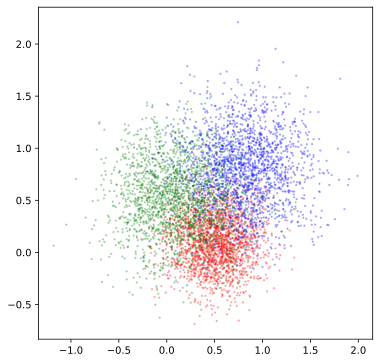

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.colors import ListedColormap

%config InlineBackend.figure_format = 'svg'

# ------------------------
# Example labeled point cloud
# ------------------------
np.random.seed(1)
n = 2000

points = np.concatenate([
    np.random.normal(loc=[0.5, 0.1], scale=0.25, size=(n, 2)),
    np.random.normal(loc=[0.8, 0.8], scale=0.35, size=(n, 2)),
    np.random.normal(loc=[0.1, 0.5], scale=0.35, size=(n, 2)),
])

labels = np.array(['red'] * n + ['blue'] * n + ['green'] * n)

ordered_labels = ['red', 'blue', 'green', 'white']  

# ------------------------
# Setup
# ------------------------
ordered_labels = ['red', 'blue', 'green', 'white']   # final colormap order (white = empty)
label_to_index = {lbl: i for i, lbl in enumerate(ordered_labels)}
white_index = label_to_index['white']

# Only labels that actually have points for KDE
kde_labels = [lbl for lbl in ordered_labels if lbl != 'white']
kde_to_ordered = np.array([label_to_index[lbl] for lbl in kde_labels])

# ------------------------
plt.figure(figsize=(6, 6))
for c in ['red', 'blue', 'green']:
    m = labels == c
    plt.scatter(points[m, 0], points[m, 1], s=2, alpha=0.25, color=c, label=c)
plt.show()

In [29]:
print(points.shape)
print(labels.shape)

(6000, 2)
(6000,)


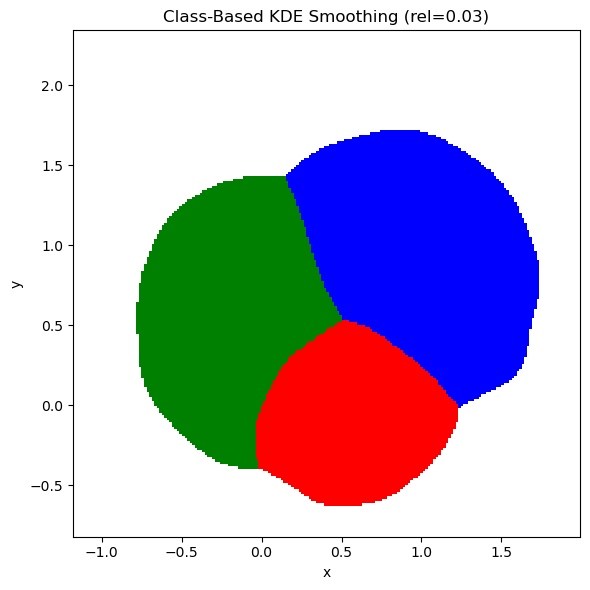

In [ ]:
# ------------------------
# Evaluate KDE on a grid 
# ------------------------
grid_res = 200

xmin, xmax = points[:, 0].min(), points[:, 0].max()
ymin, ymax = points[:, 1].min(), points[:, 1].max()

# Add small margins
# pad_x = 0.05 * (xmax - xmin)
# pad_y = 0.05 * (ymax - ymin)
# xmin, xmax = xmin - pad_x, xmax + pad_x
# ymin, ymax = ymin - pad_y, ymax + pad_y

x = np.linspace(xmin, xmax, grid_res)
y = np.linspace(ymin, ymax, grid_res)
xx, yy = np.meshgrid(x, y)
grid_coords = np.vstack([xx.ravel(), yy.ravel()])  # (2, N)

# ------------------------
# KDE per label
# ------------------------
densities = np.zeros((len(kde_labels), grid_coords.shape[1]))

for i, lab in enumerate(kde_labels):
    pts = points[labels == lab]
    kde = gaussian_kde(pts.T, bw_method=0.5)
    densities[i] = kde(grid_coords)

# ------------------------
# Class assignment 
# ------------------------
max_density = np.max(densities, axis=0)
overall_max = max_density.max()

rel = 0.03      # relative threshold (1% of global max). tweak: 0.005~0.03
thr = rel * overall_max

# argmax gives index in kde_labels
class_map = np.argmax(densities, axis=0)

# map kde_labels index -> ordered_labels index
class_map = kde_to_ordered[class_map]

class_map[max_density < thr] = white_index

class_map = class_map.reshape((grid_res, grid_res))

# ------------------------
# Plot
# ------------------------
cmap = ListedColormap(ordered_labels)

plt.figure(figsize=(6, 6))
plt.imshow(class_map, origin='lower', extent=(xmin, xmax, ymin, ymax), cmap=cmap, interpolation='nearest')
plt.title(f"Class-Based KDE Smoothing (rel={rel})")
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()
plt.savefig("figures/example1_separate_cluster_KDE.pdf", format="pdf")
plt.show()

In [ ]:
id = np.arange(1, len(labels) + 1)
df_cells = np.column_stack((id, points, labels))
df_cells = pd.DataFrame(df_cells)

df_cells.columns = ['cell_id','x','y','cluster']

type_map = {'red': 'A', 'blue': 'B', 'green': 'C'}
df_cells.cluster = df_cells.cluster.map(type_map)

print(df_cells.head())

df_cells.to_csv("/Users/yoolkyupark/Main/UNC/Spring26/COMP 683/journalclub1/all_cells_example2.csv")



  cell_id                   x                     y cluster
0       1  0.9060863409158104  -0.05293910341251884       A
1       2   0.367957061934136  -0.16824215553904262       A
2       3  0.7163519073311696   -0.4753846742200707       A
3       4  0.9362029410541199  -0.09030172522377569       A
4       5  0.5797597740142746   0.03765740613064748       A


In [102]:
class_map = pd.DataFrame(class_map)

class_map.to_csv("/Users/yoolkyupark/Main/UNC/Spring26/COMP 683/journalclub1/all_cells_example_classmap.csv")